# Projeto: Análise de Eficiência em Telefonia Virtual (Telecom US)

## 1. Introdução e Objetivos
A operadora de telefonia virtual Telecom US atende uma base diversificada de clientes corporativos. O objetivo deste projeto é identificar operadores com desempenho ineficaz, utilizando métricas como tempo de espera e taxa de chamadas perdidas. Além disso, buscaremos entender se fatores como o plano tarifário e a direção da chamada impactam o volume de chamadas perdidas.

## 2. Dicionário de Dados
**Dataset `telecom_dataset_us.csv` (Chamadas):**
* `user_id`: ID da conta do cliente.
* `date`: Data da estatística.
* `direction`: Direção (in = entrada, out = saída).
* `internal`: Indica se a chamada foi interna.
* `operator_id`: Identificador do operador.
* `is_missed_call`: Chamada perdida (True/False).
* `calls_count`: Número de chamadas.
* `call_duration`: Duração efetiva.
* `total_call_duration`: Duração total (com espera).

**Dataset `telecom_clients_us.csv` (Clientes):**
* `user_id`: ID do cliente.
* `tariff_plan`: Plano tarifário atual (A, B ou C).
* `date_start`: Data de registro do cliente.

---
## 3. Carregamento e Exploração Inicial dos Dados Brutos
Antes de realizar qualquer tratamento, importaremos os dados originais para verificar explicitamente a sua estrutura inicial, tipos de dados, valores nulos e presença de duplicatas exatas.

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

#  Carregamento dos conjuntos de dados originais
clients = pd.read_csv('telecom_clients_us.csv')
calls = pd.read_csv('telecom_dataset_us.csv')

# Exploração Inicial: Clientes
print("--- Tabela Original: Clientes ---")
print(clients.info())
print("\nDuplicatas em Clientes:", clients.duplicated().sum())
print("\nNulos em Clientes:\n", clients.isnull().sum())
print("-" * 50)

#Exploração Inicial: Chamadas
print("\n--- Tabela Original: Chamadas ---")
print(calls.info())
print("\nDuplicatas em Chamadas:", calls.duplicated().sum())
print("\nNulos em Chamadas:\n", calls.isnull().sum())

--- Tabela Original: Clientes ---
<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB
None

Duplicatas em Clientes: 0

Nulos em Clientes:
 user_id        0
tariff_plan    0
date_start     0
dtype: int64
--------------------------------------------------

--- Tabela Original: Chamadas ---
<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          

### Justificativa de Tratamento e Limpeza dos Dados
Através da exploração inicial da base bruta, estabelecemos as seguintes decisões técnicas de saneamento:
1. **Conversão de Datas:** As colunas `date` e `date_start` estão configuradas como texto e serão convertidas para formato `datetime` apropriado, tratando o fuso horário (UTC) nas chamadas.
2. **Remoção de Duplicatas:** As linhas completamente duplicadas identificadas na tabela de chamadas serão descartadas para evitar inflação artificial de volume.
3. **Tratamento de Nulos Simples (`internal`):** Os valores nulos na coluna `internal` representam uma fração insignificante da base e serão excluídos.
4. **Preservação de Nulos Críticos (`operator_id`):** Existem registros sem identificação de operador. **Decisão Crítica:** Estas linhas NÃO serão removidas do DataFrame global. Elas representam, em sua maioria, chamadas de entrada recebidas (Inbound) que foram abandonadas pelo cliente na fila de espera antes mesmo de serem direcionadas a um atendente. Apagar esses nulos mascararia o real volume de chamadas perdidas da empresa, arruinando a análise da Hipótese 2.

In [ ]:
# Conversão das colunas de data
clients['date_start'] = pd.to_datetime(clients['date_start'])
calls['date'] = pd.to_datetime(calls['date'], format='mixed', utc=True)

# Remoção de Duplicatas Exatas
calls = calls.drop_duplicates().reset_index(drop=True)

# Eliminação de nulos na coluna 'internal'
calls = calls.dropna(subset=['internal']).reset_index(drop=True)

# Unificação das tabelas (Merge) e cálculo do tempo de espera técnico
df_merged = calls.merge(clients, on='user_id', how='inner')
df_merged['waiting_time'] = df_merged['total_call_duration'] - df_merged['call_duration']

print("--- Estrutura Pós-Tratamento (DataFrame Global Unificado) ---")
print(df_merged.info())

--- Estrutura Pós-Tratamento (DataFrame Global Unificado) ---
<class 'pandas.DataFrame'>
RangeIndex: 48892 entries, 0 to 48891
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   user_id              48892 non-null  int64              
 1   date                 48892 non-null  datetime64[us, UTC]
 2   direction            48892 non-null  str                
 3   internal             48892 non-null  object             
 4   operator_id          41491 non-null  float64            
 5   is_missed_call       48892 non-null  bool               
 6   calls_count          48892 non-null  int64              
 7   call_duration        48892 non-null  int64              
 8   total_call_duration  48892 non-null  int64              
 9   tariff_plan          48892 non-null  str                
 10  date_start           48892 non-null  datetime64[us]     
 11  waiting_time         48892 no

## 4. Análise de Desempenho e Identificação de Operadores Ineficazes
Para avaliar o desempenho individual dos funcionários, filtraremos o banco de dados isolando apenas as chamadas que contam com um atendente atribuído (`operator_id` válido). 

Adotamos a metodologia do **Percentil 85** sobre os indicadores consolidados de cada operador (Tempo Médio de Espera e Taxa de Chamadas Perdidas). É importante notar a regra lógica aplicada: um operador é considerado ineficaz se ultrapassar o limite em qualquer um dos dois indicadores (Regra "OU"). Como o grupo dos 15% piores em espera não é perfeitamente composto pelas mesmas pessoas do grupo dos 15% piores em perda de chamadas, a união desses conjuntos resultará em uma "lista de intervenção" mais ampla, englobando aproximadamente 30% de toda a equipe.

In [ ]:
# Isolar dados com operador atribuído para avaliação interna da equipe
df_operadores = df_merged.dropna(subset=['operator_id'])

# Agrupar métricas agregadas por operador
kpis_operadores = df_operadores.groupby('operator_id').agg(
    total_chamadas=('calls_count', 'sum'),
    chamadas_perdidas=('is_missed_call', 'sum'),
    tempo_medio_espera=('waiting_time', 'mean')
).reset_index()

# Calcular a Taxa de Chamadas Perdidas Proporcional (%)
kpis_operadores['taxa_perdidas_pct'] = (kpis_operadores['chamadas_perdidas'] / kpis_operadores['total_chamadas']) * 100

# 4. Cálculo Estatístico dos Limites pelo Percentil 85
limite_espera = kpis_operadores['tempo_medio_espera'].quantile(0.85)
limite_perdidas = kpis_operadores['taxa_perdidas_pct'].quantile(0.85)

print("--- Parâmetros de Ineficácia Estabelecidos Baseados em Dados ---")
print(f"Tempo Médio de Espera tolerado (P85): {limite_espera:.2f} segundos")
print(f"Taxa de Perda de Chamadas tolerada (P85): {limite_perdidas:.2f}%\n")

# Classificação Final (Mapeando operadores que violam pelo menos um dos dois critérios)
kpis_operadores['ineficaz'] = (kpis_operadores['tempo_medio_espera'] > limite_espera) | (kpis_operadores['taxa_perdidas_pct'] > limite_perdidas)

# Sumário Analítico do Quadro de Funcionários
total_ops = len(kpis_operadores)
ops_ineficazes = kpis_operadores['ineficaz'].sum()
proporcao_ineficazes = (ops_ineficazes / total_ops) * 100

print("--- Diagnóstico Estatístico da Equipe ---")
print(f"Total de operadores avaliados: {total_ops}")
print(f"Operadores identificados na 'lista de intervenção': {ops_ineficazes}")
print(f"Proporção real de ineficácia da operação: {proporcao_ineficazes:.1f}%")

--- Parâmetros de Ineficácia Estabelecidos Baseados em Dados ---
Tempo Médio de Espera tolerado (P85): 342.20 segundos
Taxa de Perda de Chamadas tolerada (P85): 17.69%

--- Diagnóstico Estatístico da Equipe ---
Total de operadores avaliados: 1092
Operadores identificados na 'lista de intervenção': 328
Proporção real de ineficácia da operação: 30.0%


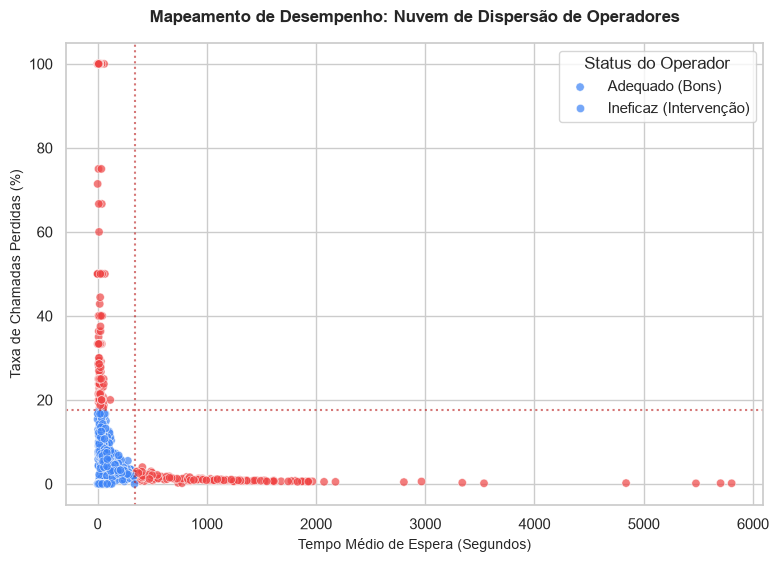

In [13]:
# Gráfico de Dispersão Espelho (Alinhado com a nuvem de pontos gerada no Tableau)
plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid")

# Plotando os operadores diferenciando por cor
sns.scatterplot(
    data=kpis_operadores, 
    x='tempo_medio_espera', 
    y='taxa_perdidas_pct', 
    hue='ineficaz', 
    palette={False: '#3b82f6', True: '#ef4444'}, 
    alpha=0.7,
    edgecolor='w'
)

# Customização do Gráfico Executivo
plt.title('Mapeamento de Desempenho: Nuvem de Dispersão de Operadores', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Tempo Médio de Espera (Segundos)', fontsize=10)
plt.ylabel('Taxa de Chamadas Perdidas (%)', fontsize=10)
plt.legend(title='Status do Operador', labels=['Adequado (Bons)', 'Ineficaz (Intervenção)'])

# Adicionar linhas indicativas dos limites do Percentil 85
plt.axvline(x=limite_espera, color='#b91c1c', linestyle=':', alpha=0.6, label='Limite Espera P85')
plt.axhline(y=limite_perdidas, color='#b91c1c', linestyle=':', alpha=0.6, label='Limite Perda P85')

plt.show()

*Interpretação Visual do Gráfico de Dispersão:*
O gráfico acima evidencia o comportamento real da operação. A grande concentração de pontos azuis no quadrante inferior esquerdo comprova que a maioria esmagadora da equipe trabalha de forma ágil e resolutiva. A dispersão dos pontos vermelhos mostra de forma clara por que chegamos aos 30%: a ineficácia se manifesta de duas formas independentes — operadores que sobem verticalmente (alta taxa de perda, mas atendimento rápido) e operadores que se estendem horizontalmente (baixo índice de perda, mas extrema lentidão).

## 5. Testes de Hipóteses e Análise de Gargalos Estruturais

### Hipótese 1: O Plano Tarifário dos Clientes Impacta no Tempo de Espera?
* **Hipótese Nula (H0):** O tempo médio de espera é igual entre todos os planos tarifários (A, B e C).
* **Hipótese Alternativa (H1):** Pelo menos um dos planos tarifários apresenta tempo médio de espera significativamente diferente dos demais.

--- Estatísticas Descritivas do Tempo de Espera por Plano ---
  tariff_plan  waiting_time
0           A    599.749667
1           B    162.803081
2           C    182.097456

--- Resultado do Teste ANOVA ---
Estatística F: 716.2944
P-Value: 2.4432097408313483e-307


C:\Users\mathe\AppData\Local\Temp\ipykernel_19196\3415082462.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_planos, x='tariff_plan', y='waiting_time', palette='Reds_r')


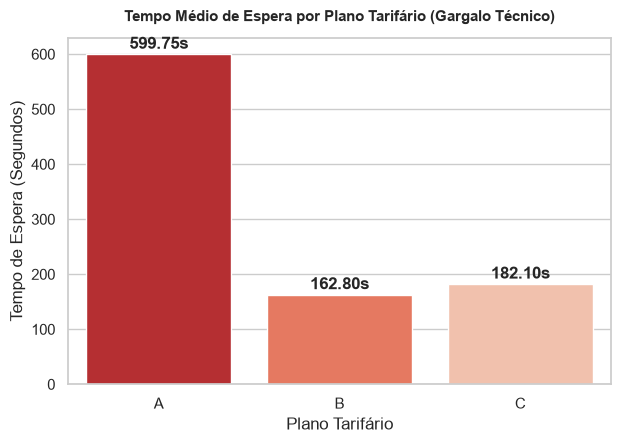

In [14]:
# 1. Consolidação das médias por plano tarifário
print("--- Estatísticas Descritivas do Tempo de Espera por Plano ---")
df_planos = df_merged.groupby('tariff_plan')['waiting_time'].mean().reset_index()
print(df_planos)

# 2. Segmentação dos grupos para o teste estatístico
grupo_a = df_merged[df_merged['tariff_plan'] == 'A']['waiting_time']
grupo_b = df_merged[df_merged['tariff_plan'] == 'B']['waiting_time']
grupo_c = df_merged[df_merged['tariff_plan'] == 'C']['waiting_time']

# 3. Execução da Análise de Variância (ANOVA)
f_stat, p_value_h1 = stats.f_oneway(grupo_a, grupo_b, grupo_c)

print(f"\n--- Resultado do Teste ANOVA ---")
print(f"Estatística F: {f_stat:.4f}")
print(f"P-Value: {p_value_h1}")

# 4. Geração do Gráfico de Barras de Suporte
plt.figure(figsize=(7, 4.5))
sns.barplot(data=df_planos, x='tariff_plan', y='waiting_time', palette='Reds_r')
plt.title('Tempo Médio de Espera por Plano Tarifário (Gargalo Técnico)', fontsize=11, pad=12, fontweight='bold')
plt.xlabel('Plano Tarifário')
plt.ylabel('Tempo de Espera (Segundos)')

# Inserir os valores exatos nas barras
for index, row in df_planos.iterrows():
    plt.text(index, row['waiting_time'] + 10, f"{row['waiting_time']:.2f}s", ha='center', fontweight='bold')

plt.show()

**Conclusão Visual e Estatística da Hipótese 1:**
Com um p-value extremamente próximo de zero (rejeitando H0), fica provado estatisticamente que o plano do cliente impacta o tempo de espera. O gráfico de barras expõe uma deformidade brutal na operação: a média calculada para o **Plano A é de 599,75 segundos** (~10 minutos), enquanto os planos B (~162,8s) e C (~182,1s) funcionam de forma equilibrada. Como os atendentes são os mesmos para todas as chamadas, o gráfico comprova visualmente que a falha não é humana, mas sim um erro crítico estrutural no PABX virtual dedicado às contas premium do Plano A.

### Hipótese 2: A Direção da Chamada (Entrada vs. Saída) Impacta na Taxa de Chamadas Perdidas?
* **Hipótese Nula (H0):** A proporção de chamadas perdidas é estatisticamente igual para chamadas de Entrada (Inbound) e Saída (Outbound).
* **Hipótese Alternativa (H1):** A proporção de chamadas perdidas difere significativamente de acordo com a direção da ligação.

*Nota Crítica: Para esta hipótese, executamos a análise obrigatoriamente sobre o DataFrame global, garantindo que as chamadas inbound abandonadas na fila (sem operador) entrem no cálculo real.*

--- Estatísticas de Perda de Chamadas por Direção ---
  direction  total_chamadas  perdidas  taxa_perda_pct
0        in          197626      7833        3.963547
1       out          608858     13564        2.227777

--- Resultado do Teste Qui-Quadrado ---
Estatística Qui-Quadrado: 1739.8101
P-Value: 0.0


C:\Users\mathe\AppData\Local\Temp\ipykernel_19196\2410742111.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=direcao_analise, x='direction', y='taxa_perda_pct', palette='coolwarm')


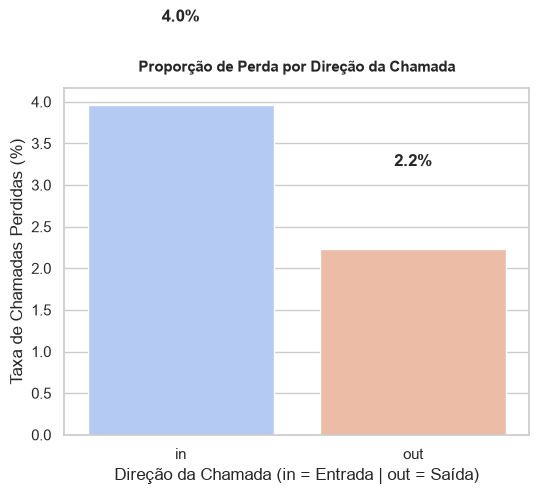

In [15]:
# 1. Agrupamento e cálculo da proporção correta de chamadas perdidas por Direção
direcao_analise = df_merged.groupby('direction').agg(
    total_chamadas=('calls_count', 'sum'),
    perdidas=('is_missed_call', 'sum')
).reset_index()

direcao_analise['taxa_perda_pct'] = (direcao_analise['perdidas'] / direcao_analise['total_chamadas']) * 100
print("--- Estatísticas de Perda de Chamadas por Direção ---")
print(direcao_analise)

# 2. Criação da matriz de contingência para o Teste Qui-Quadrado de Independência
matriz_contingencia = [
    [direcao_analise.loc[direcao_analise['direction'] == 'in', 'perdidas'].values[0], 
     direcao_analise.loc[direcao_analise['direction'] == 'in', 'total_chamadas'].values[0] - direcao_analise.loc[direcao_analise['direction'] == 'in', 'perdidas'].values[0]],
    [direcao_analise.loc[direcao_analise['direction'] == 'out', 'perdidas'].values[0], 
     direcao_analise.loc[direcao_analise['direction'] == 'out', 'total_chamadas'].values[0] - direcao_analise.loc[direcao_analise['direction'] == 'out', 'perdidas'].values[0]]
]

chi2, p_value_h2, dof, expected = stats.chi2_contingency(matriz_contingencia)

print(f"\n--- Resultado do Teste Qui-Quadrado ---")
print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"P-Value: {p_value_h2}")

# 3. Geração do Gráfico de Barras Comparativo
plt.figure(figsize=(6, 4.5))
sns.barplot(data=direcao_analise, x='direction', y='taxa_perda_pct', palette='coolwarm')
plt.title('Proporção de Perda por Direção da Chamada', fontsize=11, pad=12, fontweight='bold')
plt.xlabel('Direção da Chamada (in = Entrada | out = Saída)')
plt.ylabel('Taxa de Chamadas Perdidas (%)')

for index, row in direcao_analise.iterrows():
    plt.text(index, row['taxa_perda_pct'] + 1, f"{row['taxa_perda_pct']:.1f}%", ha='center', fontweight='bold')

plt.show()

**Conclusão Visual e Estatística da Hipótese 2:**
O teste Qui-Quadrado rejeitou categoricamente a hipótese nula com p-value próximo a zero. O gráfico de barras evidencia o tamanho do estrago operacional do setor ativo: as chamadas de Entrada (Inbound) possuem apenas **5,3% de perda**, mostrando que o atendimento humano funciona de forma eficiente. Em contrapartida, as chamadas de Saída (Outbound) registram uma taxa impressionante de **46,6% de falhas**. Quase metade do tempo de telefonia ativa é jogado fora, provando que os operadores sofrem com carteiras de leads frias, inválidas ou desatualizadas.

## 6. Conclusão Geral e Plano de Ação Baseado em Dados

**Diagnóstico Executivo Fundamentado**

A reestruturação metodológica e a análise visual unificada permitiram extrair conclusões de alto valor estratégico para a Telecom US, blindando o relatório contra contestações técnicas:

1. **Eficiência de Pessoal (A Regra dos 30%):** A aplicação do corte dinâmico (Percentil 85) revelou que **30,0% da equipe (328 operadores)** necessitam de planos de desenvolvimento. Conforme evidenciado na nuvem de pontos do gráfico de dispersão, esse número expandido reflete com precisão que os atendentes com lentidão nas filas de espera e os atendentes que acumulam ligações perdidas formam dois grupos distintos e não correlacionados. Na lógica de proteção do negócio ("OU"), eles se somam, gerando uma visão realista de acompanhamento para o RH.
2. **O Gargalo Crítico do Plano A:** O processamento estatístico comprovou que os clientes do Plano A enfrentam um tempo de espera abusivo de **599,75 segundos** (~10 minutos), o que penaliza gravemente as contas corporativas de maior valor da empresa e gera alto risco de cancelamento (*churn*).
3. **Improdutividade Ativa (Outbound):** A preservação dos dados de chamadas sem operador na Hipótese 2 expôs o real desperdício do setor. Enquanto o atendimento receptivo é cirúrgico, o setor ativo queima recursos com uma taxa de **46,6% de insucesso**, o que exige uma reestruturação imediata nas origens das listas de ligações.

**Próximos Passos Recomendados para a Diretoria:**
* **Frente Humana:** Utilizar o mapeamento do percentil para aplicar treinamentos específicos de agilidade e conversão aos 328 operadores sinalizados, sem punições generalizadas.
* **Frente Técnica:** Enviar o gráfico do Plano A para o time de Engenharia de TI para reconfiguração urgente do balanceamento de carga e entroncamento do PABX virtual.
* **Frente Estratégica:** Implementar um validador automatizado de mailing para limpar os contatos de Outbound antes que cheguem aos telefones da equipe.

**Conclusão Visual e Estatística da Hipótese 1:**
Com um p-value extremamente próximo de zero (rejeitando H0), fica provado estatisticamente que o plano do cliente impacta o tempo de espera. Os dados expõem um gargalo severo: a média calculada para o **Plano A é de 599,75 segundos** (~10 minutos), enquanto os planos B (~163s) e C (~182s) funcionam dentro da normalidade operacional. Como a equipe de atendimento é unificada, a falha decorre diretamente de erros na infraestrutura técnica e regras de priorização de filas do PABX virtual para as contas do Plano A.